In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models


In [ ]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


Train shape: (42000, 785)
Test shape: (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
y = train['label']
X = train.drop(['label'], axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (42000, 784)
y shape: (42000,)


In [ ]:
# Normalize (0–255 → 0–1)
X = X / 255.0
test = test / 255.0

# Reshape into 28×28×1 format
X = X.values.reshape(-1, 28, 28, 1)
test = test.values.reshape(-1, 28, 28, 1)

print("Reshaped X:", X.shape)


Reshaped X: (42000, 28, 28, 1)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)


In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       495,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515,146 (1.97 MB)

 Trainable params: 515,146 (1.97 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val))


Epoch 1/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - accuracy: 0.8874 - loss: 0.3598 - val_accuracy: 0.9781 - val_loss: 0.0711
Epoch 2/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 80s 34ms/step - accuracy: 0.9854 - loss: 0.0494 - val_accuracy: 0.9845 - val_loss: 0.0528
Epoch 3/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.9909 - loss: 0.0301 - val_accuracy: 0.9874 - val_loss: 0.0414
Epoch 4/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.9936 - loss: 0.0193 - val_accuracy: 0.9852 - val_loss: 0.0444
Epoch 5/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.9958 - loss: 0.0133 - val_accuracy: 0.9871 - val_loss: 0.0468


In [ ]:
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"✅ Validation Accuracy: {val_acc:.4f}")


132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9863 - loss: 0.0502
✅ Validation Accuracy: 0.9871


In [ ]:
predictions = model.predict(test)
pred_labels = np.argmax(predictions, axis=1)


875/875 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step


In [ ]:
submission = pd.DataFrame({
    'ImageId': range(1, len(pred_labels)+1),
    'Label': pred_labels
})
submission.to_csv('submission.csv', index=False)
print("✅ submission.csv file saved!")


✅ submission.csv file saved!


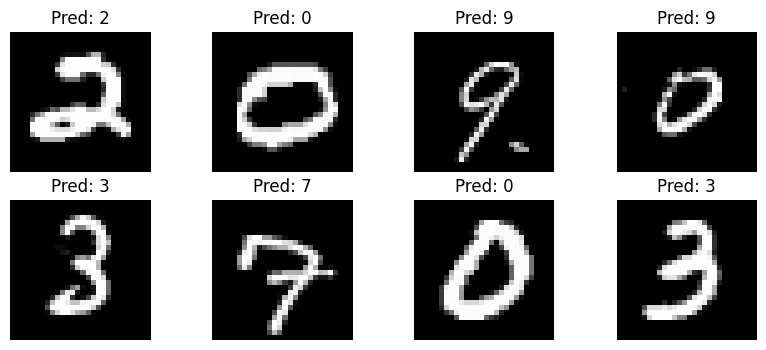

In [ ]:
plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {pred_labels[i]}")
    plt.axis('off')
plt.show()
